# 🎵 Music Genre Classification - Version 5 (Data-Centric + Model Selection)

## 🎯 Goals
1. **Data-Centric Analysis**: Analyze class-wise performance and handle class imbalance.
2. **Model Selection (A-Team)**: Focus on strong models (XGBoost, LightGBM, CatBoost, RandomForest) and exclude weak ones.
3. **Class Weights**: Apply `class_weight='balanced'` to core models to improve recall on minority classes.
4. **Ensemble Stabilization**: Build a robust ensemble with optimized weights from the A-Team.
5. **Target Score**: Surpass V3 (0.55555).

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import json

# Add src to path
sys.path.append(os.path.abspath("src"))

from preprocess.feature.feature import Feature
from pipeline.BasePipeline import BasePipeline
from model.LightGBM import ModelLightGBM
from model.XGBoost import ModelXGBoost
from model.Catboost import ModelCatboost
from model.Random_Forest import ModelRandomForest
from ensemble.ensemble import Ensemble
from evaluation.Evaluation import Evaluation
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_predict

warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

# Set random seed
SEED = 42
np.random.seed(SEED)

## 1. Load Data & Preprocessing (Same as V3/V4)

In [2]:
DATA_DIR = "data"
train_df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
test_df = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))
sample_sub = pd.read_csv(os.path.join(DATA_DIR, "sample_submission.csv"))

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

# Encode Target
le = LabelEncoder()
train_df['Class_Encoded'] = le.fit_transform(train_df['Class'])
target_col = 'Class_Encoded'

# Combine for preprocessing
train_df['is_train'] = 1
test_df['is_train'] = 0
full_df = pd.concat([train_df.drop(columns=['Class', 'Class_Encoded']), test_df], axis=0).reset_index(drop=True)

# Drop ID and Name columns
drop_cols = ['Id', 'Artist Name', 'Track Name']
full_df = full_df.drop(columns=drop_cols)

# Handle Missing Values (Median Imputation)
numeric_cols = full_df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    full_df[col] = full_df[col].fillna(full_df[col].median())

# Feature Engineering: Log Transform for Skewed Features
skewed_features = ['Popularity', 'loudness', 'duration_in min/ms', 'tempo']
for col in skewed_features:
    if col in full_df.columns:
        min_val = full_df[col].min()
        shift = abs(min_val) + 1 if min_val <= 0 else 0
        full_df[f'{col}_log'] = np.log1p(full_df[col] + shift)

# Scaling
scaler = StandardScaler()
scaled_cols = full_df.select_dtypes(include=np.number).columns.drop('is_train')
full_df[scaled_cols] = scaler.fit_transform(full_df[scaled_cols])

# Split back
X = full_df[full_df['is_train'] == 1].drop(columns=['is_train'])
X_test = full_df[full_df['is_train'] == 0].drop(columns=['is_train'])
y = train_df['Class_Encoded']

# Feature Selection (Reuse V3 logic)
ft = Feature(pd.concat([X, y.rename(target_col)], axis=1), target_col=target_col, task='classification')
ft.correlation_analysis(threshold=0.95, show_report=False)
X_selected = ft.get_data().drop(columns=[target_col])
X_test_selected = X_test[X_selected.columns]

print(f"Selected Features: {X_selected.columns.tolist()}")

Train shape: (14396, 18)
Test shape: (3600, 17)


## 🔬 Correlation Analysis (threshold=0.95)

### ✅ Đã loại bỏ **2** features có correlation cao: ['loudness_log', 'tempo_log']

Selected Features: ['Popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_in min/ms', 'time_signature', 'Popularity_log', 'duration_in min/ms_log']


## 2. Data-Centric Analysis

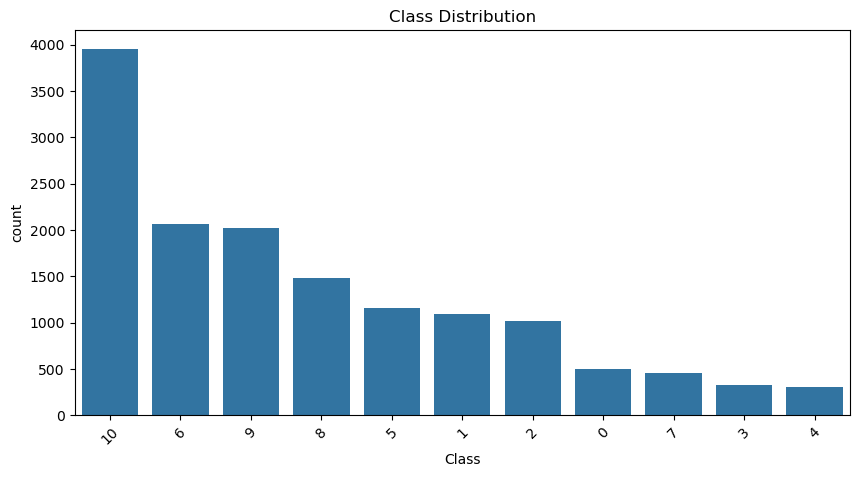


🔹 Training Reference Model (CatBoost) for Analysis...
0:	learn: 2.3023288	test: 2.3034120	best: 2.3034120 (0)	total: 131ms	remaining: 1m 5s
100:	learn: 1.2220124	test: 1.2755662	best: 1.2755662 (100)	total: 1.44s	remaining: 5.71s
200:	learn: 1.1109843	test: 1.2164943	best: 1.2164943 (200)	total: 2.84s	remaining: 4.22s
300:	learn: 1.0407941	test: 1.1959357	best: 1.1959357 (300)	total: 4.23s	remaining: 2.79s
400:	learn: 0.9851727	test: 1.1887396	best: 1.1887052 (397)	total: 5.51s	remaining: 1.36s
499:	learn: 0.9381052	test: 1.1865805	best: 1.1862658 (492)	total: 6.84s	remaining: 0us

bestTest = 1.186265842
bestIteration = 492

Shrink model to first 493 iterations.

🔹 Evaluation Report for catboost (classification)
              precision    recall  f1-score   support

           0       0.65      0.74      0.69       100
           1       0.43      0.01      0.03       220
           2       0.52      0.47      0.49       204
           3       0.77      0.77      0.77        64
      

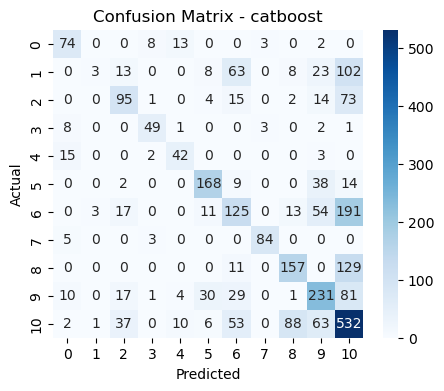

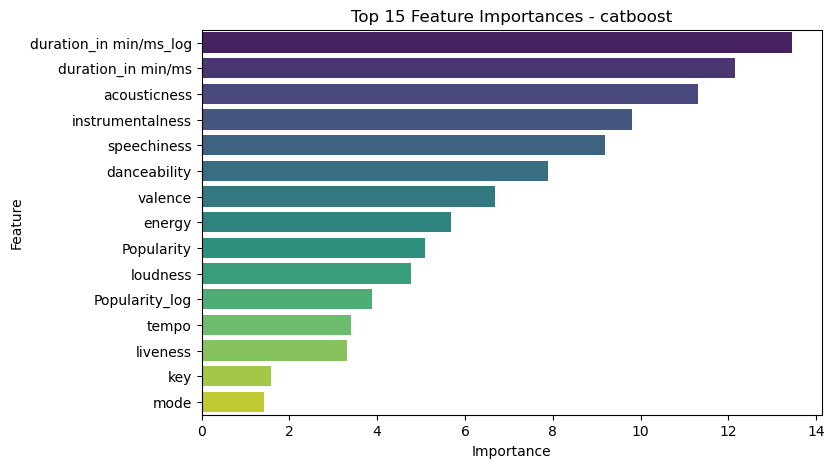


📊 Per-Class Metrics:


,precision,recall,f1-score,support
1,0.428571,0.013636,0.026432,220.000000
6,0.409836,0.301932,0.347705,414.000000
2,0.524862,0.465686,0.493506,204.000000
weighted avg,0.536298,0.541667,0.517728,2880.000000
accuracy,0.541667,0.541667,0.541667,0.541667
9,0.537209,0.571782,0.553957,404.000000
8,0.583643,0.528620,0.554770,297.000000
10,0.473731,0.671717,0.555614,792.000000
macro avg,0.604184,0.579703,0.571115,2880.000000
4,0.600000,0.677419,0.636364,62.000000


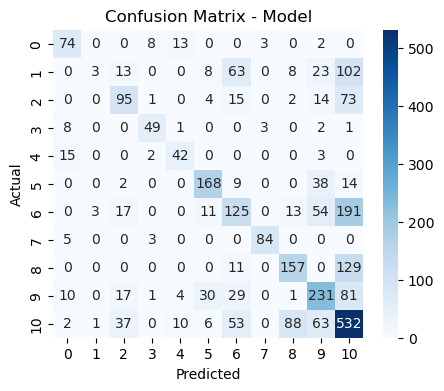

In [3]:
# Class Distribution
plt.figure(figsize=(10, 5))
sns.countplot(x=train_df['Class'], order=train_df['Class'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()

# Reference Model (CatBoost) Analysis
print("\n🔹 Training Reference Model (CatBoost) for Analysis...")
cat_ref = ModelCatboost(task="classification", random_state=SEED)
X_train_split, X_val_split, y_train_split, y_val_split = cat_ref.prepare_data(pd.concat([X_selected, y], axis=1), target_col)
cat_ref.train(X_train=X_train_split, y_train=y_train_split, X_test=X_val_split, y_test=y_val_split)

# Per-class Metrics
print("\n📊 Per-Class Metrics:")
evaluator = Evaluation(cat_ref.model, X_val_split, y_val_split, task="classification")
class_metrics = evaluator.get_class_metrics()
display(class_metrics.sort_values(by="f1-score"))

# Confusion Matrix
evaluator.plot_confusion()

## 3. Model Selection (A-Team) & Class Weight Experiments
We select **XGBoost, LightGBM, CatBoost, and RandomForest** as our core models.
We will train them with `class_weight='balanced'` (or equivalent) to handle class imbalance.


🚀 Training LightGBM with Class Weights...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000531 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3017
[LightGBM] [Info] Number of data points in the train set: 11516, number of used features: 16
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
Training until validation scores don't improve for 50 rounds
Early stoppin

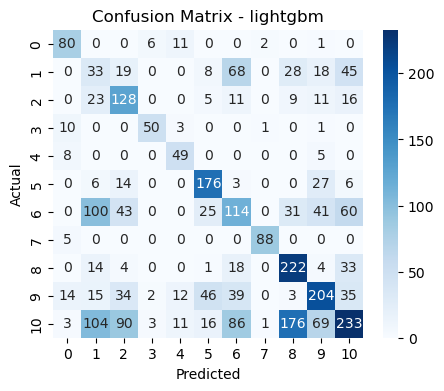

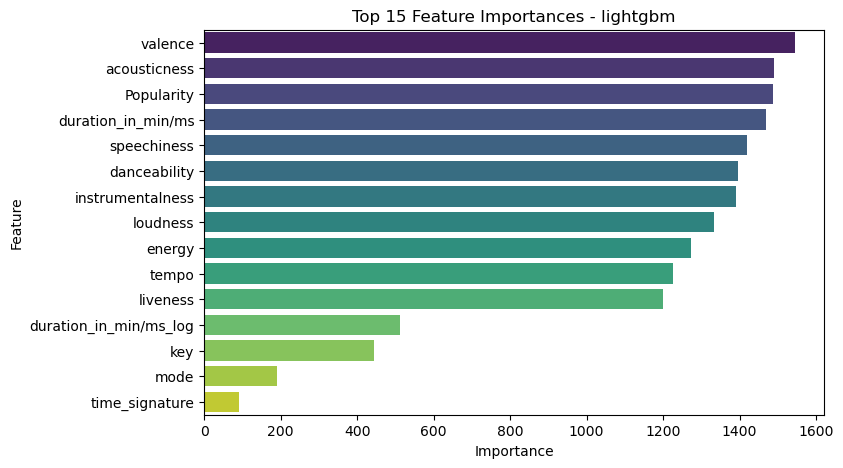

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000457 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3019
[LightGBM] [Info] Number of data points in the train set: 11517, number of used features: 16
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[49]	valid_0's multi_

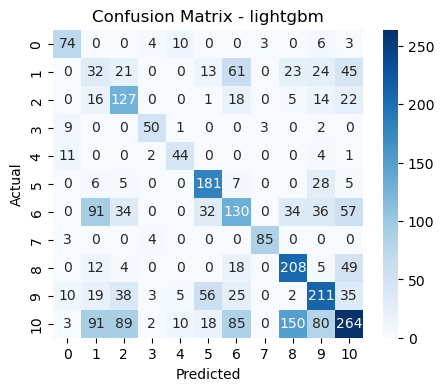

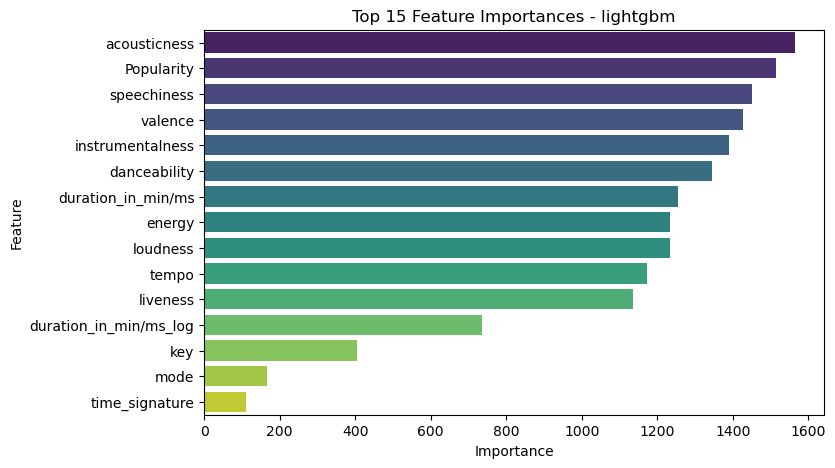

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000319 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3019
[LightGBM] [Info] Number of data points in the train set: 11517, number of used features: 16
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[55]	val

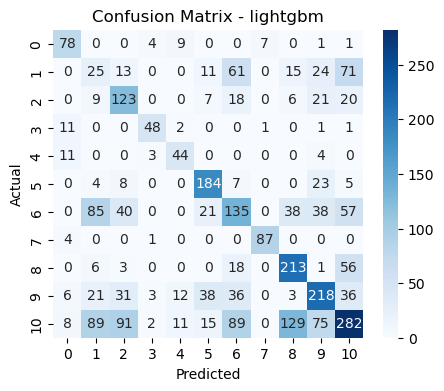

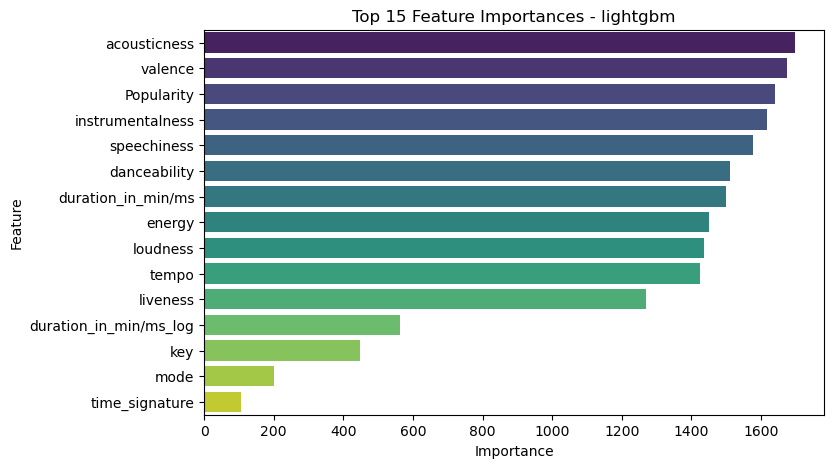

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000294 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3019
[LightGBM] [Info] Number of data points in the train set: 11517, number of used features: 16
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[51]	val

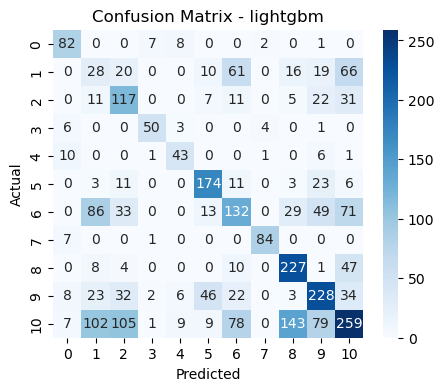

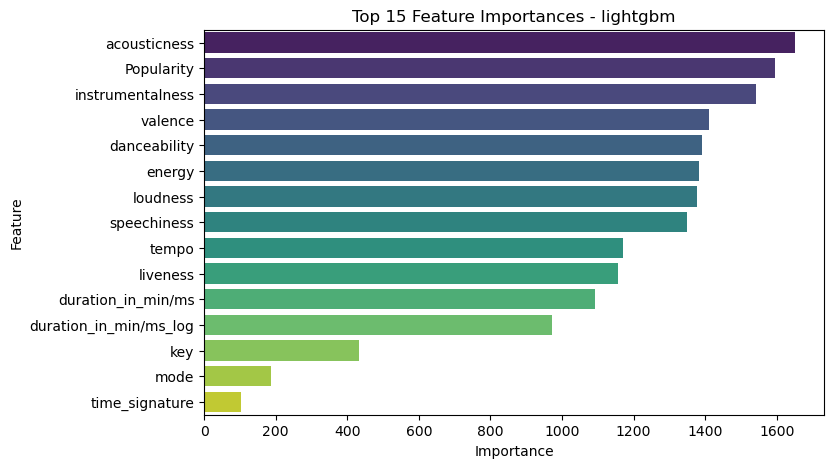

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000354 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3021
[LightGBM] [Info] Number of data points in the train set: 11517, number of used features: 16
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
[LightGBM] [Info] Start training from score -2.397895
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[62]	val

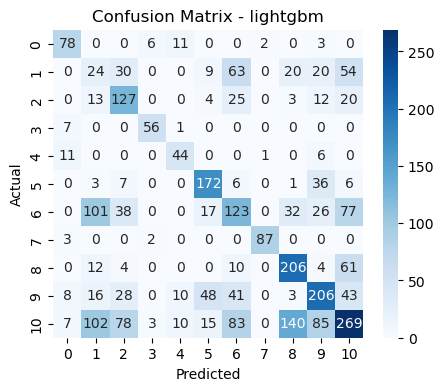

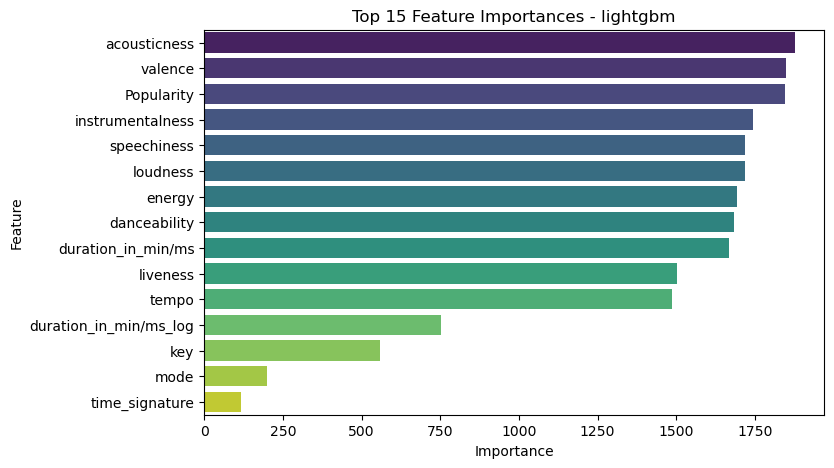

✅ LightGBM CV F1-Macro: 0.56953

🚀 Training XGBoost with Class Weights...
ℹ️ Đã tính toán sample_weight cho XGBoost (balanced).

🔹 Evaluation Report for xgboost (classification)
              precision    recall  f1-score   support

           0       0.66      0.82      0.73       100
           1       0.10      0.12      0.11       219
           2       0.43      0.60      0.50       203
           3       0.81      0.74      0.77        65
           4       0.60      0.73      0.66        62
           5       0.69      0.71      0.70       232
           6       0.31      0.29      0.30       414
           7       0.95      0.95      0.95        93
           8       0.52      0.66      0.58       296
           9       0.54      0.52      0.53       404
          10       0.48      0.36      0.41       792

    accuracy                           0.48      2880
   macro avg       0.55      0.59      0.57      2880
weighted avg       0.48      0.48      0.48      2880


 Tổng hợ

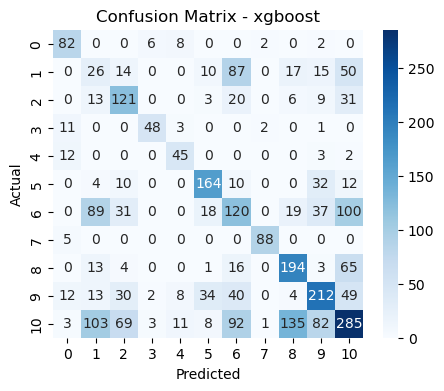

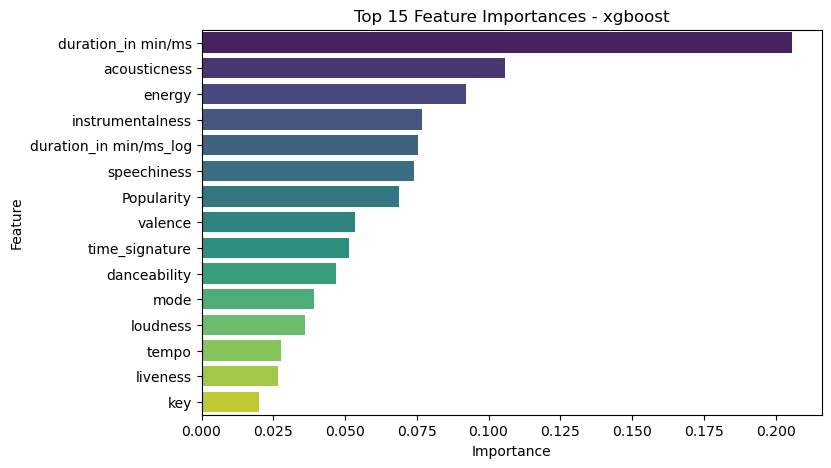

ℹ️ Đã tính toán sample_weight cho XGBoost (balanced).

🔹 Evaluation Report for xgboost (classification)
              precision    recall  f1-score   support

           0       0.70      0.73      0.72       100
           1       0.10      0.10      0.10       219
           2       0.43      0.56      0.49       203
           3       0.76      0.77      0.76        65
           4       0.68      0.74      0.71        62
           5       0.65      0.75      0.70       232
           6       0.34      0.33      0.33       414
           7       0.97      0.95      0.96        92
           8       0.52      0.60      0.55       296
           9       0.52      0.54      0.53       404
          10       0.50      0.40      0.44       792

    accuracy                           0.49      2879
   macro avg       0.56      0.59      0.57      2879
weighted avg       0.49      0.49      0.49      2879


 Tổng hợp metrics:
                    xgboost
Accuracy           0.490448
Precisi

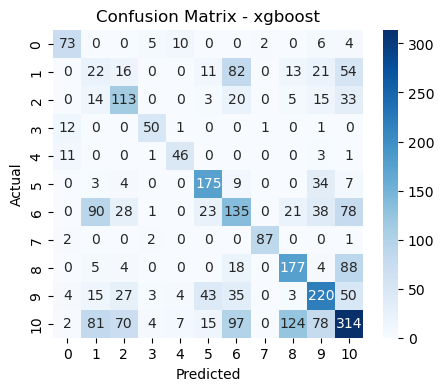

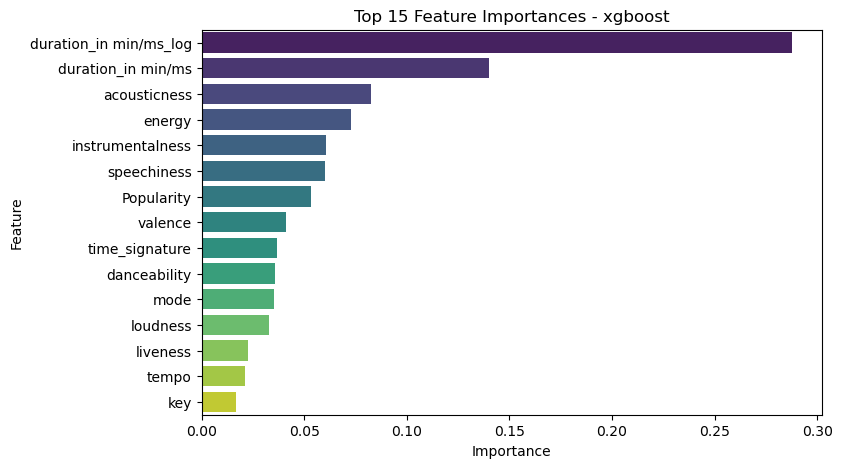

ℹ️ Đã tính toán sample_weight cho XGBoost (balanced).

🔹 Evaluation Report for xgboost (classification)
              precision    recall  f1-score   support

           0       0.70      0.80      0.74       100
           1       0.09      0.10      0.09       220
           2       0.43      0.52      0.47       204
           3       0.81      0.78      0.79        64
           4       0.61      0.71      0.66        62
           5       0.68      0.76      0.72       231
           6       0.32      0.31      0.32       414
           7       0.92      0.92      0.92        92
           8       0.54      0.64      0.58       297
           9       0.53      0.54      0.54       404
          10       0.49      0.39      0.43       791

    accuracy                           0.49      2879
   macro avg       0.56      0.59      0.57      2879
weighted avg       0.49      0.49      0.49      2879


 Tổng hợp metrics:
                    xgboost
Accuracy           0.489406
Precisi

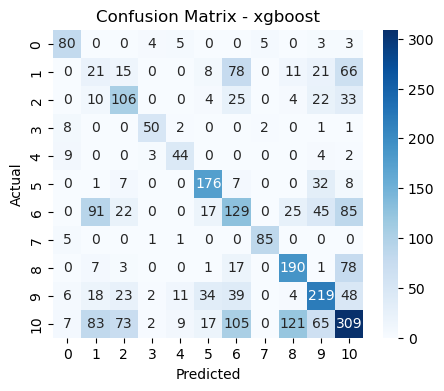

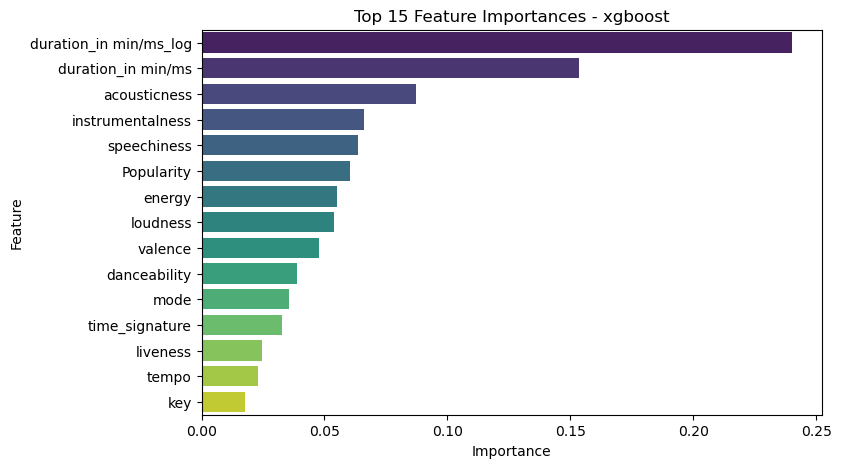

ℹ️ Đã tính toán sample_weight cho XGBoost (balanced).

🔹 Evaluation Report for xgboost (classification)
              precision    recall  f1-score   support

           0       0.68      0.82      0.75       100
           1       0.06      0.05      0.06       220
           2       0.41      0.53      0.46       204
           3       0.79      0.77      0.78        64
           4       0.63      0.60      0.61        62
           5       0.68      0.70      0.69       231
           6       0.35      0.33      0.34       413
           7       0.91      0.91      0.91        92
           8       0.58      0.65      0.61       297
           9       0.54      0.57      0.56       404
          10       0.48      0.41      0.44       792

    accuracy                           0.49      2879
   macro avg       0.56      0.58      0.56      2879
weighted avg       0.49      0.49      0.49      2879


 Tổng hợp metrics:
                    xgboost
Accuracy           0.493922
Precisi

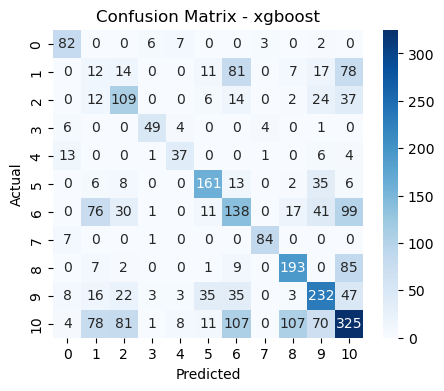

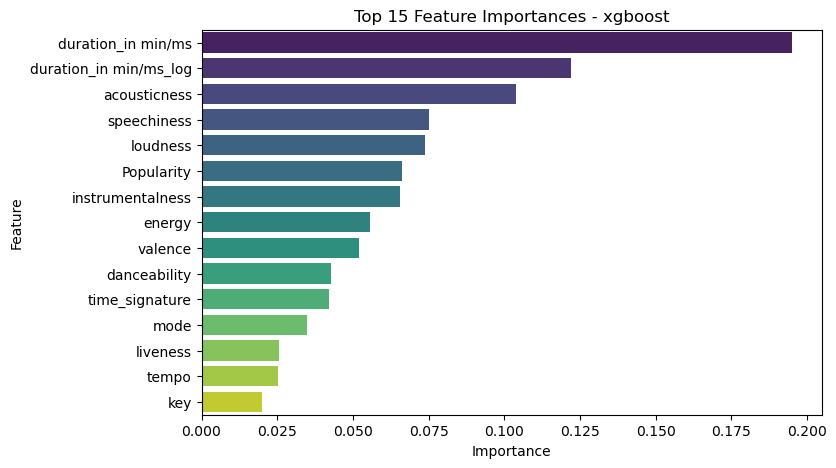

ℹ️ Đã tính toán sample_weight cho XGBoost (balanced).

🔹 Evaluation Report for xgboost (classification)
              precision    recall  f1-score   support

           0       0.67      0.80      0.73       100
           1       0.08      0.09      0.08       220
           2       0.46      0.59      0.52       204
           3       0.87      0.84      0.86        64
           4       0.65      0.76      0.70        62
           5       0.67      0.71      0.69       231
           6       0.31      0.29      0.30       414
           7       0.96      0.95      0.95        92
           8       0.52      0.61      0.56       297
           9       0.51      0.50      0.50       403
          10       0.48      0.39      0.43       792

    accuracy                           0.48      2879
   macro avg       0.56      0.59      0.58      2879
weighted avg       0.48      0.48      0.48      2879


 Tổng hợp metrics:
                    xgboost
Accuracy           0.481765
Precisi

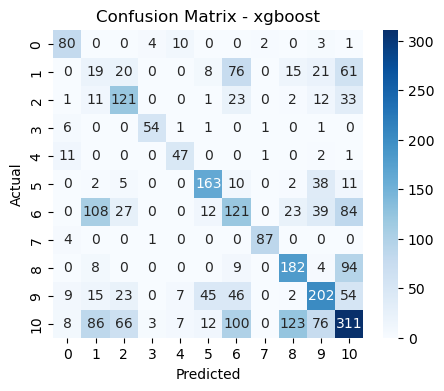

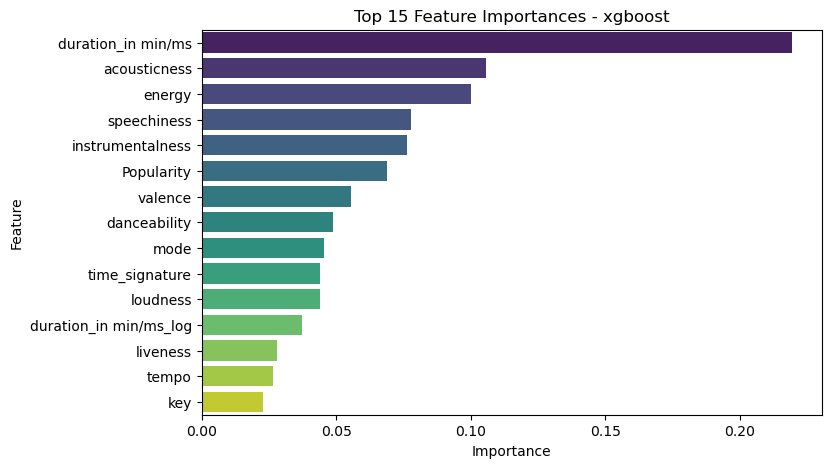

✅ XGBoost CV F1-Macro: 0.56974

🚀 Training CatBoost with Class Weights...
ℹ️ Đã tính toán class_weights cho CatBoost (balanced).
Learning rate set to 0.113385
0:	learn: 2.1488811	test: 2.1478178	best: 2.1478178 (0)	total: 14.8ms	remaining: 14.7s
100:	learn: 0.8873604	test: 1.0096225	best: 1.0096225 (100)	total: 1.31s	remaining: 11.7s
200:	learn: 0.7625606	test: 0.9780400	best: 0.9780400 (200)	total: 2.62s	remaining: 10.4s
300:	learn: 0.6815117	test: 0.9760901	best: 0.9755212 (241)	total: 3.97s	remaining: 9.21s
400:	learn: 0.6179698	test: 0.9808417	best: 0.9752848 (311)	total: 5.29s	remaining: 7.91s
500:	learn: 0.5616807	test: 0.9922153	best: 0.9752848 (311)	total: 6.63s	remaining: 6.6s
600:	learn: 0.5193377	test: 1.0009589	best: 0.9752848 (311)	total: 7.97s	remaining: 5.29s
700:	learn: 0.4804811	test: 1.0119749	best: 0.9752848 (311)	total: 9.3s	remaining: 3.97s
800:	learn: 0.4453506	test: 1.0255918	best: 0.9752848 (311)	total: 10.6s	remaining: 2.64s
900:	learn: 0.4145025	test: 1.038439

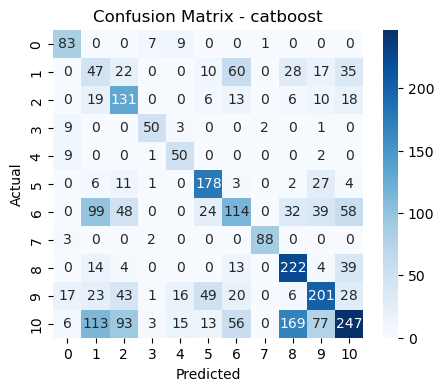

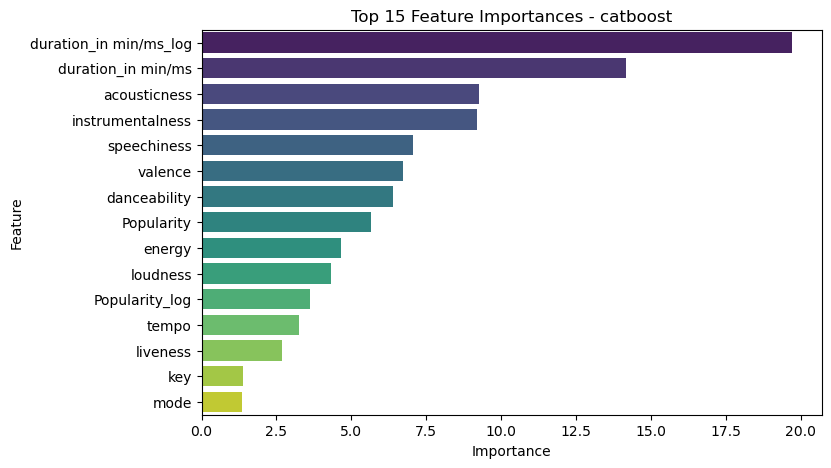

ℹ️ Đã tính toán class_weights cho CatBoost (balanced).
Learning rate set to 0.113385
0:	learn: 2.1370895	test: 2.1416898	best: 2.1416898 (0)	total: 16.2ms	remaining: 16.2s
100:	learn: 0.8871936	test: 1.0394619	best: 1.0394619 (100)	total: 1.41s	remaining: 12.5s
200:	learn: 0.7590977	test: 1.0080856	best: 1.0080856 (200)	total: 2.73s	remaining: 10.9s
300:	learn: 0.6815161	test: 1.0009192	best: 1.0009192 (300)	total: 4.09s	remaining: 9.5s
400:	learn: 0.6163944	test: 1.0054235	best: 0.9998704 (321)	total: 5.38s	remaining: 8.03s
500:	learn: 0.5635233	test: 1.0149857	best: 0.9998704 (321)	total: 6.8s	remaining: 6.77s
600:	learn: 0.5186038	test: 1.0242305	best: 0.9998704 (321)	total: 8.07s	remaining: 5.36s
700:	learn: 0.4785270	test: 1.0349678	best: 0.9998704 (321)	total: 9.32s	remaining: 3.98s
800:	learn: 0.4441847	test: 1.0450039	best: 0.9998704 (321)	total: 10.7s	remaining: 2.65s
900:	learn: 0.4124974	test: 1.0572769	best: 0.9998704 (321)	total: 11.9s	remaining: 1.31s
999:	learn: 0.386162

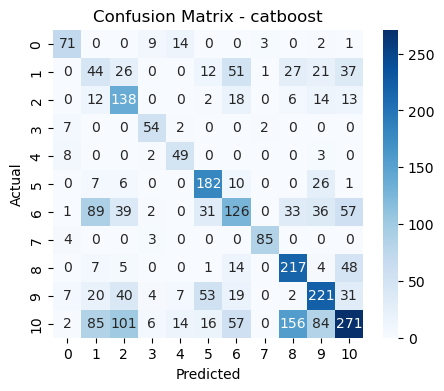

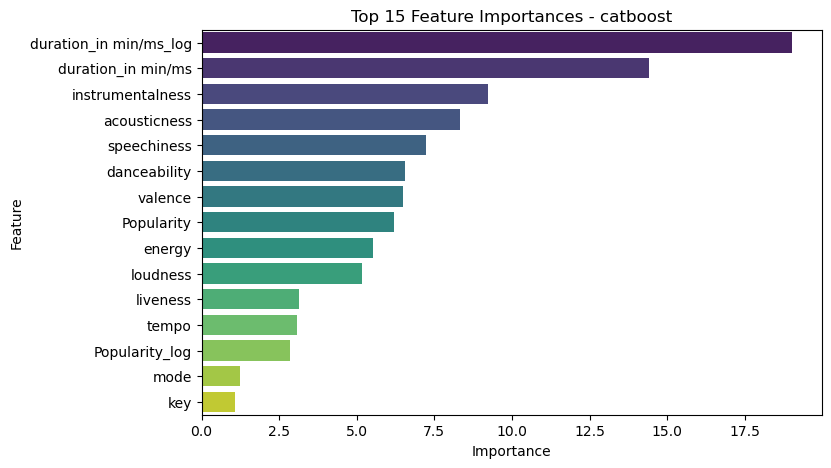

ℹ️ Đã tính toán class_weights cho CatBoost (balanced).
Learning rate set to 0.113385
0:	learn: 2.1163154	test: 2.1436986	best: 2.1436986 (0)	total: 16.6ms	remaining: 16.6s
100:	learn: 0.8883004	test: 1.0485833	best: 1.0485833 (100)	total: 1.44s	remaining: 12.8s
200:	learn: 0.7624128	test: 1.0153792	best: 1.0151897 (199)	total: 2.69s	remaining: 10.7s
300:	learn: 0.6798872	test: 1.0095945	best: 1.0095945 (300)	total: 4.14s	remaining: 9.61s
400:	learn: 0.6191909	test: 1.0161083	best: 1.0080221 (327)	total: 5.46s	remaining: 8.16s
500:	learn: 0.5661582	test: 1.0235759	best: 1.0080221 (327)	total: 6.77s	remaining: 6.74s
600:	learn: 0.5208123	test: 1.0355328	best: 1.0080221 (327)	total: 8.05s	remaining: 5.35s
700:	learn: 0.4796162	test: 1.0494035	best: 1.0080221 (327)	total: 9.35s	remaining: 3.99s
800:	learn: 0.4457193	test: 1.0607622	best: 1.0080221 (327)	total: 10.6s	remaining: 2.64s
900:	learn: 0.4148873	test: 1.0731949	best: 1.0080221 (327)	total: 12s	remaining: 1.32s
999:	learn: 0.388655

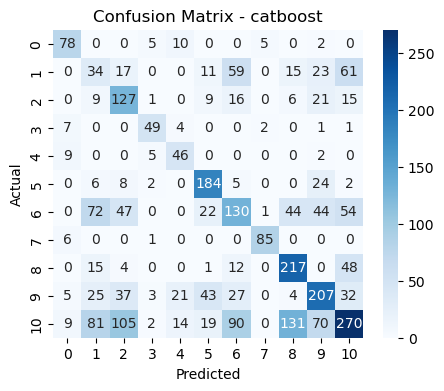

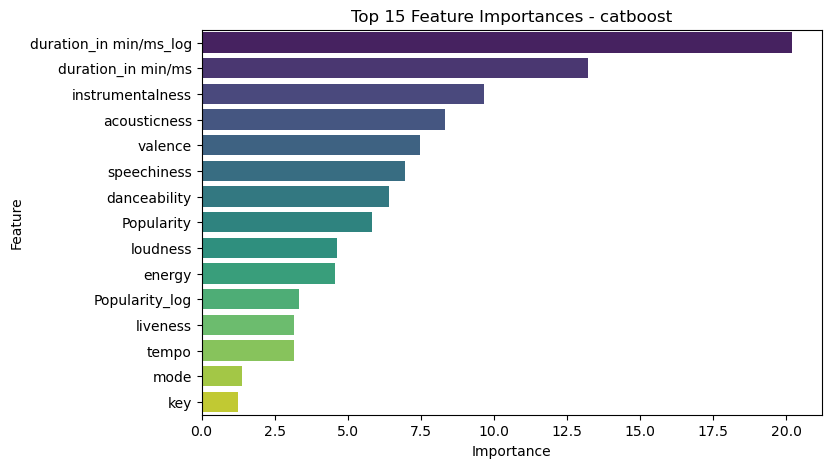

ℹ️ Đã tính toán class_weights cho CatBoost (balanced).
Learning rate set to 0.113385
0:	learn: 2.1368416	test: 2.1472988	best: 2.1472988 (0)	total: 15.7ms	remaining: 15.7s
100:	learn: 0.8865641	test: 1.0250618	best: 1.0250618 (100)	total: 1.65s	remaining: 14.7s
200:	learn: 0.7608694	test: 0.9952931	best: 0.9952931 (200)	total: 2.92s	remaining: 11.6s
300:	learn: 0.6823081	test: 0.9910260	best: 0.9909269 (298)	total: 4.21s	remaining: 9.78s
400:	learn: 0.6142459	test: 0.9937722	best: 0.9908189 (336)	total: 5.47s	remaining: 8.17s
500:	learn: 0.5614842	test: 1.0003819	best: 0.9908189 (336)	total: 6.83s	remaining: 6.8s
600:	learn: 0.5131168	test: 1.0102684	best: 0.9908189 (336)	total: 8.14s	remaining: 5.4s
700:	learn: 0.4735590	test: 1.0213249	best: 0.9908189 (336)	total: 9.41s	remaining: 4.02s
800:	learn: 0.4383259	test: 1.0324457	best: 0.9908189 (336)	total: 10.7s	remaining: 2.66s
900:	learn: 0.4098528	test: 1.0440206	best: 0.9908189 (336)	total: 12s	remaining: 1.31s
999:	learn: 0.3848990	

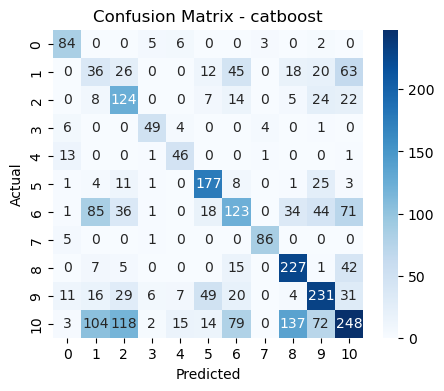

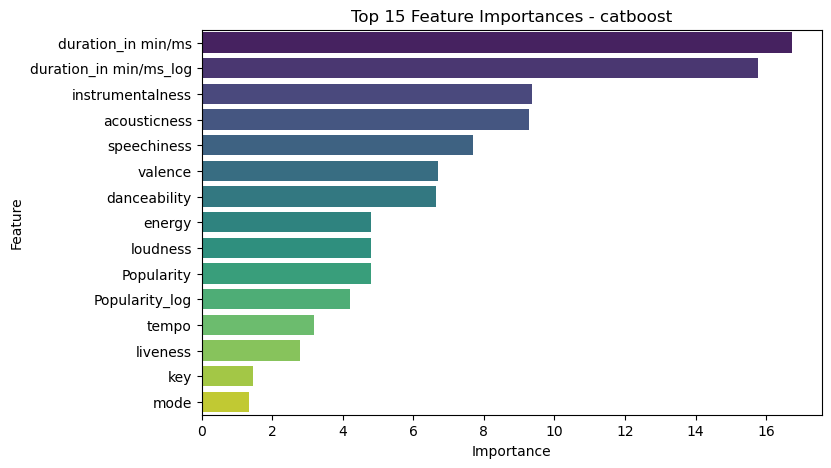

ℹ️ Đã tính toán class_weights cho CatBoost (balanced).
Learning rate set to 0.113385
0:	learn: 2.1297437	test: 2.1390059	best: 2.1390059 (0)	total: 14.9ms	remaining: 14.9s
100:	learn: 0.8865930	test: 1.0388207	best: 1.0388207 (100)	total: 1.29s	remaining: 11.5s
200:	learn: 0.7626658	test: 1.0053041	best: 1.0053041 (200)	total: 2.6s	remaining: 10.3s
300:	learn: 0.6823684	test: 0.9958119	best: 0.9958119 (300)	total: 3.85s	remaining: 8.95s
400:	learn: 0.6185506	test: 0.9989542	best: 0.9958119 (300)	total: 5.2s	remaining: 7.76s
500:	learn: 0.5657655	test: 1.0013358	best: 0.9958119 (300)	total: 6.44s	remaining: 6.42s
600:	learn: 0.5221650	test: 1.0070058	best: 0.9958119 (300)	total: 7.86s	remaining: 5.22s
700:	learn: 0.4816508	test: 1.0134965	best: 0.9958119 (300)	total: 9.13s	remaining: 3.89s
800:	learn: 0.4468894	test: 1.0262225	best: 0.9958119 (300)	total: 10.6s	remaining: 2.64s
900:	learn: 0.4166848	test: 1.0362449	best: 0.9958119 (300)	total: 13.6s	remaining: 1.5s
999:	learn: 0.3887938

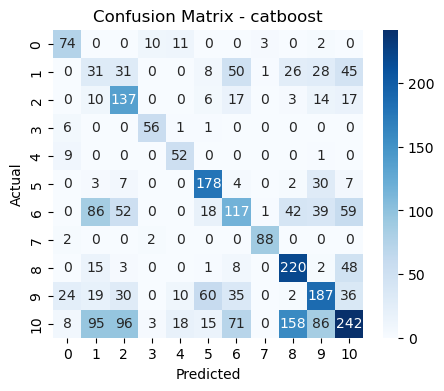

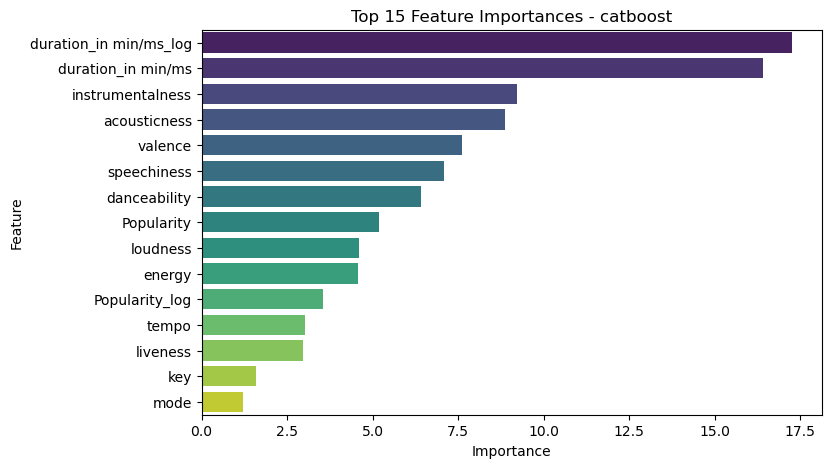

✅ CatBoost CV F1-Macro: 0.56905

🚀 Training RandomForest with Class Weights...
🚀 Huấn luyện mô hình Random Forest...

🔹 Evaluation Report for random_forest (classification)
              precision    recall  f1-score   support

           0       0.63      0.80      0.71       100
           1       0.11      0.16      0.13       219
           2       0.32      0.66      0.43       203
           3       0.78      0.75      0.77        65
           4       0.50      0.85      0.63        62
           5       0.65      0.75      0.70       232
           6       0.39      0.28      0.33       414
           7       0.96      0.92      0.94        93
           8       0.47      0.75      0.57       296
           9       0.49      0.45      0.47       404
          10       0.56      0.26      0.35       792

    accuracy                           0.46      2880
   macro avg       0.53      0.60      0.55      2880
weighted avg       0.49      0.46      0.45      2880


 Tổng hợp met

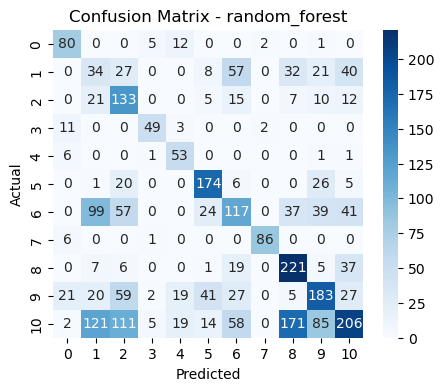

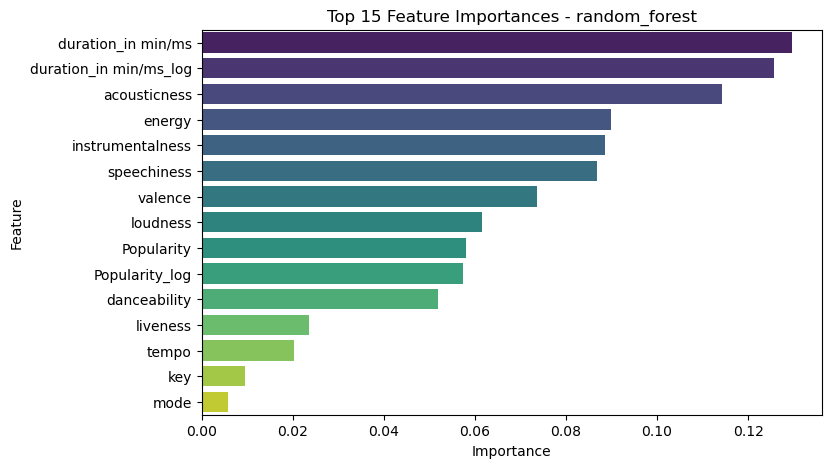

💾 Model đã được lưu tại: experiments/models\random_forest_best.pkl
🚀 Huấn luyện mô hình Random Forest...

🔹 Evaluation Report for random_forest (classification)
              precision    recall  f1-score   support

           0       0.66      0.78      0.72       100
           1       0.13      0.14      0.14       219
           2       0.33      0.68      0.44       203
           3       0.71      0.74      0.72        65
           4       0.55      0.81      0.65        62
           5       0.59      0.76      0.67       232
           6       0.46      0.30      0.36       414
           7       0.96      0.92      0.94        92
           8       0.49      0.72      0.58       296
           9       0.48      0.49      0.48       404
          10       0.54      0.31      0.39       792

    accuracy                           0.48      2879
   macro avg       0.54      0.60      0.55      2879
weighted avg       0.49      0.48      0.47      2879


 Tổng hợp metrics:
      

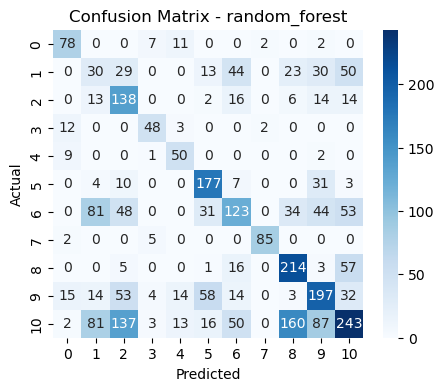

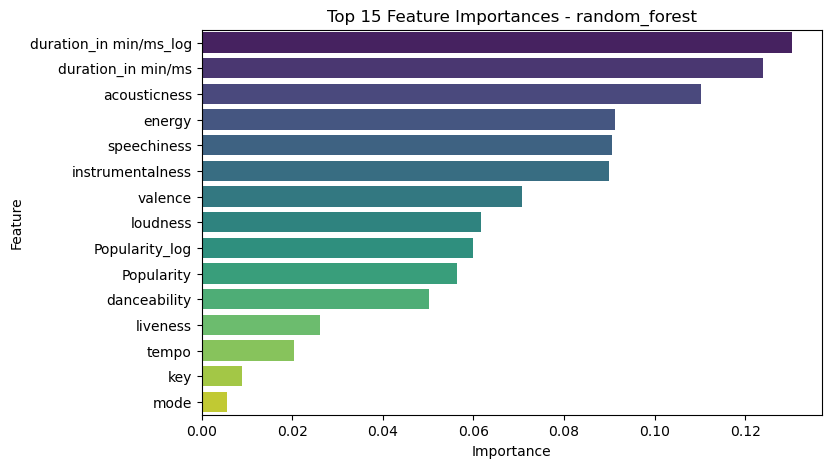

💾 Model đã được lưu tại: experiments/models\random_forest_best.pkl
🚀 Huấn luyện mô hình Random Forest...

🔹 Evaluation Report for random_forest (classification)
              precision    recall  f1-score   support

           0       0.63      0.77      0.69       100
           1       0.17      0.12      0.14       220
           2       0.30      0.65      0.41       204
           3       0.78      0.77      0.77        64
           4       0.44      0.76      0.56        62
           5       0.70      0.78      0.74       231
           6       0.39      0.33      0.36       414
           7       0.93      0.93      0.93        92
           8       0.50      0.71      0.59       297
           9       0.49      0.49      0.49       404
          10       0.53      0.31      0.40       791

    accuracy                           0.48      2879
   macro avg       0.53      0.60      0.55      2879
weighted avg       0.49      0.48      0.47      2879


 Tổng hợp metrics:
      

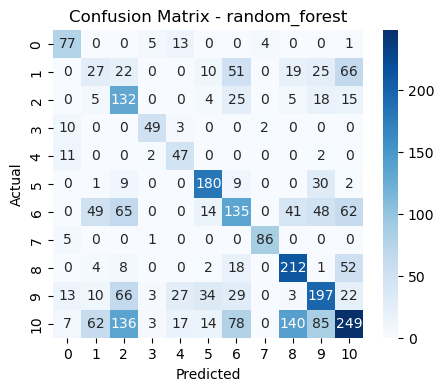

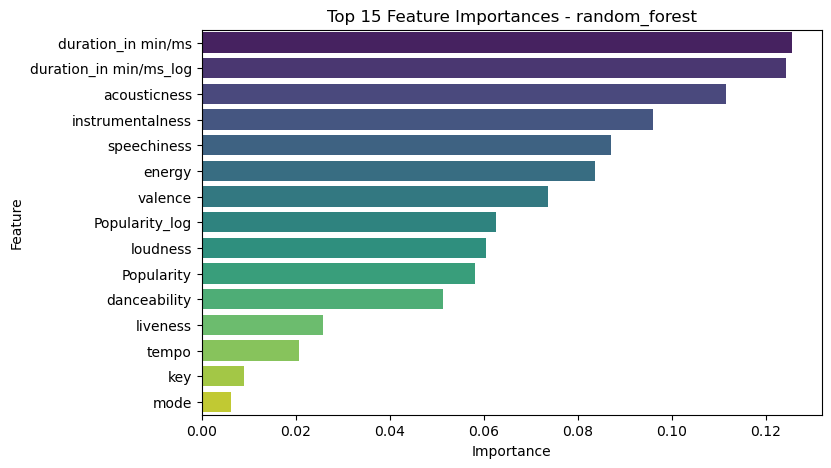

💾 Model đã được lưu tại: experiments/models\random_forest_best.pkl
🚀 Huấn luyện mô hình Random Forest...

🔹 Evaluation Report for random_forest (classification)
              precision    recall  f1-score   support

           0       0.60      0.83      0.69       100
           1       0.12      0.10      0.10       220
           2       0.30      0.66      0.41       204
           3       0.79      0.70      0.74        64
           4       0.48      0.66      0.55        62
           5       0.64      0.74      0.69       231
           6       0.40      0.30      0.34       413
           7       0.94      0.92      0.93        92
           8       0.52      0.76      0.62       297
           9       0.52      0.50      0.51       404
          10       0.52      0.31      0.39       792

    accuracy                           0.48      2879
   macro avg       0.53      0.59      0.54      2879
weighted avg       0.49      0.48      0.47      2879


 Tổng hợp metrics:
      

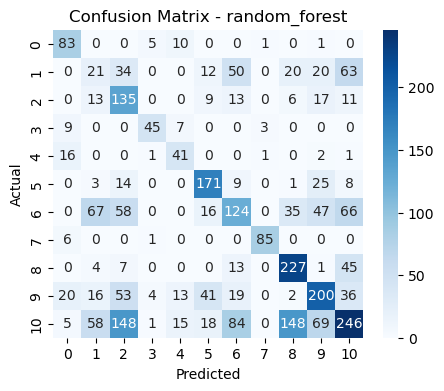

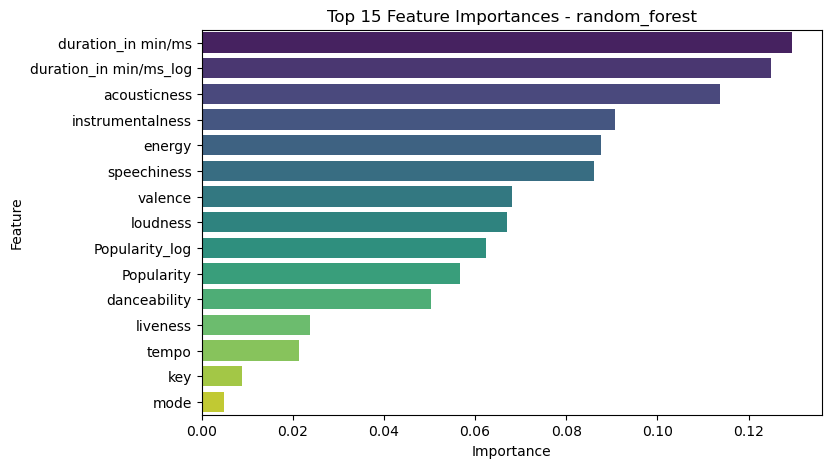

💾 Model đã được lưu tại: experiments/models\random_forest_best.pkl
🚀 Huấn luyện mô hình Random Forest...

🔹 Evaluation Report for random_forest (classification)
              precision    recall  f1-score   support

           0       0.55      0.76      0.64       100
           1       0.14      0.15      0.14       220
           2       0.33      0.70      0.45       204
           3       0.75      0.78      0.76        64
           4       0.47      0.74      0.57        62
           5       0.65      0.75      0.70       231
           6       0.40      0.29      0.34       414
           7       0.98      0.95      0.96        92
           8       0.48      0.72      0.58       297
           9       0.45      0.41      0.43       403
          10       0.52      0.28      0.36       792

    accuracy                           0.46      2879
   macro avg       0.52      0.59      0.54      2879
weighted avg       0.48      0.46      0.45      2879


 Tổng hợp metrics:
      

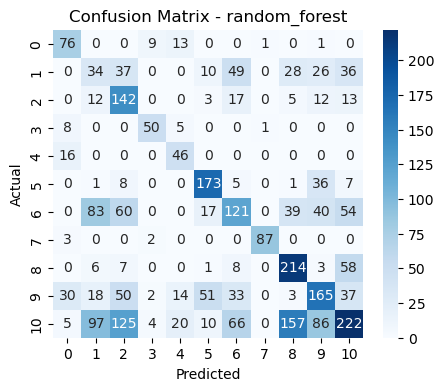

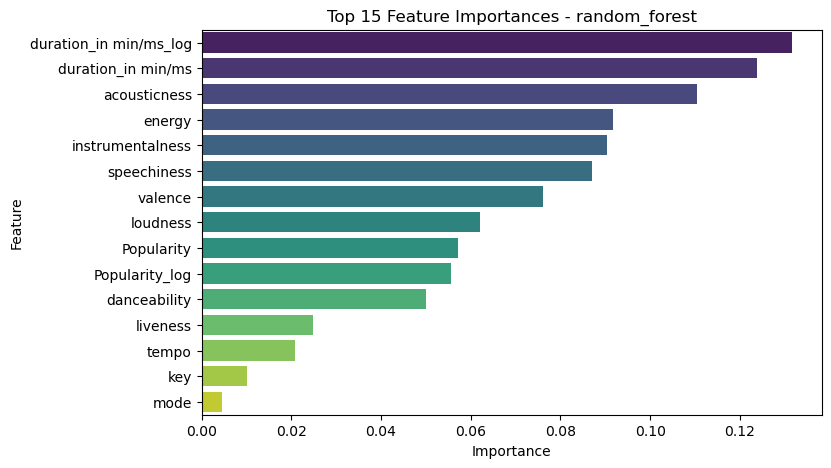

💾 Model đã được lưu tại: experiments/models\random_forest_best.pkl
✅ RandomForest CV F1-Macro: 0.54766


,Model,CV_F1
0,LightGBM,0.569530
1,XGBoost,0.569737
2,CatBoost,0.569048
3,RandomForest,0.547661


In [4]:
models = [
    ("LightGBM", ModelLightGBM(task="classification", random_state=SEED, params={"class_weight": "balanced"})),
    ("XGBoost", ModelXGBoost(task="classification", random_state=SEED, params={"class_weight": "balanced"})),
    ("CatBoost", ModelCatboost(task="classification", random_state=SEED, params={"class_weight": "balanced"})),
    ("RandomForest", ModelRandomForest(task="classification", random_state=SEED, params={"class_weight": "balanced"}))
]

oof_preds = {}
test_preds = {}
metrics_summary = []

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for name, model_wrapper in models:
    print(f"\n🚀 Training {name} with Class Weights...")
    
    # Cross-validation for OOF predictions
    # Note: We need to manually handle CV loop to collect OOF preds correctly for stacking/voting if not using a helper
    # But here we can use cross_val_predict for simplicity or manual loop.
    # Let's use a manual loop to ensure we use our wrapper's train method which handles class weights.
    
    oof_probs = np.zeros((len(X_selected), len(le.classes_)))
    test_probs_fold = np.zeros((len(X_test_selected), len(le.classes_)))
    
    fold_f1s = []
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_selected, y)):
        X_tr, y_tr = X_selected.iloc[train_idx], y.iloc[train_idx]
        X_val, y_val = X_selected.iloc[val_idx], y.iloc[val_idx]
        
        # Re-instantiate model to reset
        # We need to pass the same params. 
        # A cleaner way is to clone, but re-creating is fine here.
        if name == "LightGBM":
            clf = ModelLightGBM(task="classification", random_state=SEED, params={"class_weight": "balanced"})
        elif name == "XGBoost":
            clf = ModelXGBoost(task="classification", random_state=SEED, params={"class_weight": "balanced"})
        elif name == "CatBoost":
            clf = ModelCatboost(task="classification", random_state=SEED, params={"class_weight": "balanced"})
        elif name == "RandomForest":
            clf = ModelRandomForest(task="classification", random_state=SEED, params={"class_weight": "balanced"})
            
        clf.train(X_train=X_tr, y_train=y_tr, X_test=X_val, y_test=y_val)
        
        # Predict OOF
        oof_probs[val_idx] = clf.predict_proba(X_val)
        
        # Predict Test
        test_probs_fold += clf.predict_proba(X_test_selected)
        
        # Score
        y_pred_val = clf.predict(X_val)
        f1 = f1_score(y_val, y_pred_val, average='macro')
        fold_f1s.append(f1)
        
    # Average Test Probs
    test_probs_fold /= kf.get_n_splits()
    
    # Store
    oof_preds[name] = oof_probs
    test_preds[name] = test_probs_fold
    
    avg_f1 = np.mean(fold_f1s)
    print(f"✅ {name} CV F1-Macro: {avg_f1:.5f}")
    metrics_summary.append({"Model": name, "CV_F1": avg_f1})

pd.DataFrame(metrics_summary)

## 4. Ensemble V5 (Optimized Soft Voting)

In [5]:
ensemble = Ensemble(models=[], task="classification") # Dummy init to use helper
best_weights = ensemble.optimize_weights(oof_preds, y)

print("\n🏆 Optimized Weights:")
for m, w in best_weights.items():
    print(f"{m}: {w:.4f}")

# Calculate Ensemble OOF Score
final_oof_prob = np.zeros_like(list(oof_preds.values())[0])
for m, w in best_weights.items():
    final_oof_prob += w * oof_preds[m]

y_oof_pred = np.argmax(final_oof_prob, axis=1)
ensemble_f1 = f1_score(y, y_oof_pred, average='macro')
print(f"\n🔥 Ensemble V5 CV F1-Macro: {ensemble_f1:.5f}")


🏆 Optimized Weights:
LightGBM: 0.2500
XGBoost: 0.2500
CatBoost: 0.2500
RandomForest: 0.2500

🔥 Ensemble V5 CV F1-Macro: 0.57869


## 5. Final Submission

In [6]:
# Calculate Final Test Probabilities
final_test_prob = np.zeros_like(list(test_preds.values())[0])
for m, w in best_weights.items():
    final_test_prob += w * test_preds[m]

y_test_pred_encoded = np.argmax(final_test_prob, axis=1)
y_test_pred_labels = le.inverse_transform(y_test_pred_encoded)

# Create Submission
submission = pd.DataFrame({
    "Id": test_df["Id"],
    "Class": y_test_pred_labels
})

save_path = "experiments/Music_V5/submission_music_v5_refined_ensemble.csv"
os.makedirs("experiments/Music_V5", exist_ok=True)
submission.to_csv(save_path, index=False)
print(f"💾 Submission saved to {save_path}")

# Save Artifacts
joblib.dump(best_weights, "experiments/Music_V5/ensemble_weights.pkl")
joblib.dump(metrics_summary, "experiments/Music_V5/metrics_summary.pkl")

💾 Submission saved to experiments/Music_V5/submission_music_v5_refined_ensemble.csv


['experiments/Music_V5/metrics_summary.pkl']